In [1]:
# Step 1: Import Required Libraries

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
# Step 2: Create Synthetic Dataset

X, y = make_classification(
    n_samples=200,          # Total data points
    n_features=2,           # Total features
    n_redundant=0,          # No redundant features
    n_informative=2,        # Useful features
    n_clusters_per_class=1, # One cluster per class
    class_sep=2,            # Separation between classes
    random_state=42
)

print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Matrix Shape: (200, 2)
Target Shape: (200,)


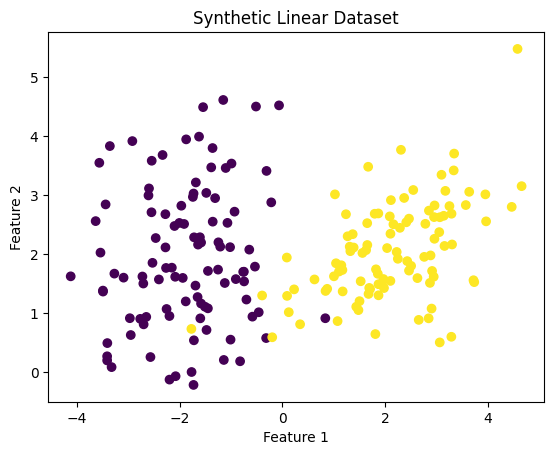

In [3]:
# Step 3: Plot Dataset

plt.scatter(X[:,0], X[:,1], c=y)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Synthetic Linear Dataset")

plt.show()

In [4]:
# Step 4: Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (160, 2)
Testing Data Shape: (40, 2)


In [5]:
# Step 5: Create Linear SVM Model

svm_model = SVC(
    kernel='linear'   # Linear kernel for linear data
)

# Train the model
svm_model.fit(X_train, y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [6]:
# Step 6: Predict Test Data

y_pred = svm_model.predict(X_test)

print("Predicted Values:")
print(y_pred)

Predicted Values:
[0 0 0 1 1 1 0 0 0 0 0 0 1 1 0 1 0 0 1 1 1 1 1 0 0 0 1 0 0 1 0 1 0 0 1 0 1
 0 1 1]


In [7]:
# Step 7: Performance Evaluation

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.975

Confusion Matrix:
[[22  1]
 [ 0 17]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.96      0.98        23
           1       0.94      1.00      0.97        17

    accuracy                           0.97        40
   macro avg       0.97      0.98      0.97        40
weighted avg       0.98      0.97      0.98        40



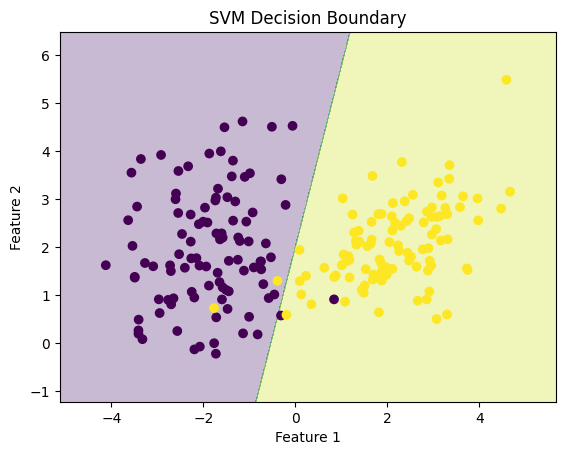

In [8]:
# Step 8: Plot Decision Boundary

def plot_decision_boundary(X, y, model):

    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, 0.01),
        np.arange(y_min, y_max, 0.01)
    )

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3)

    plt.scatter(X[:, 0], X[:, 1], c=y)

    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.title("SVM Decision Boundary")

    plt.show()


plot_decision_boundary(X, y, svm_model)

In [9]:
# Step 9: Predict New Data

new_data = [[2, 3]]

prediction = svm_model.predict(new_data)

print("Prediction for New Data:", prediction)

Prediction for New Data: [1]


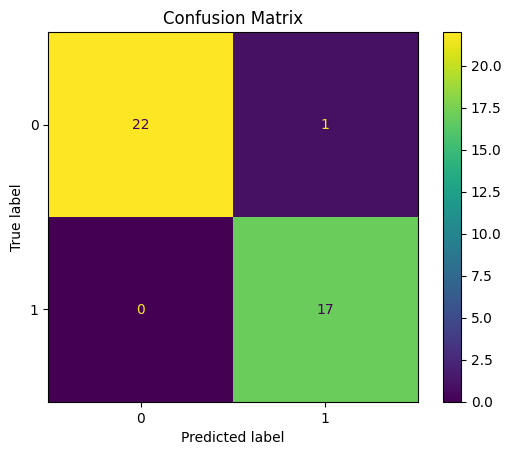

In [10]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

plt.title("Confusion Matrix")
plt.show()